# input

In [1]:
import mne
import numpy as np
from scipy.signal import welch, coherence
from itertools import combinations

fname_main = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif"
fname_rest = "/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/resting.fif"

raw_main = mne.io.read_raw_fif(fname_main, preload=True)
sfreq = raw_main.info['sfreq']

Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
    Range : 55000 ... 1630999 =     55.000 ...  1630.999 secs
Ready.
Opening raw data file /Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main-1.fif...
    Read a total of 8 projection items:
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
        generated with autossp-1.0.1 (1 x 306)  idle
   

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_15319/4117464006.py:9: RuntimeWarning: This filename (/Users/roman/PycharmProjects/brain_data/data/15.10.24/2/chistova_alena/main.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_main = mne.io.read_raw_fif(fname_main, preload=True)


Reading 0 ... 2542999  =      0.000 ...  2542.999 secs...


In [2]:
import numpy as np
import glob

# ======================
# 1️⃣ Paths
# ======================
window_dir = "windows"  # folder where you saved per-subject windows

# ======================
# 2️⃣ Collect file lists
# ======================
train_thinking_files = sorted(glob.glob(f"../{window_dir}/train_thinking_*.npy"))
test_thinking_files  = sorted(glob.glob(f"../{window_dir}/test_thinking_*.npy"))
train_rest_files     = sorted(glob.glob(f"../{window_dir}/train_rest_*.npy"))
test_rest_files      = sorted(glob.glob(f"../{window_dir}/test_rest_*.npy"))

# ======================
# 3️⃣ Load all windows and labels
# ======================
def load_windows_and_labels(thinking_files, rest_files):
    windows_list = []
    labels_list  = []

    # Thinking
    for f in thinking_files:
        w = np.load(f, mmap_mode='r')  # memory-mapped, avoids RAM overload
        windows_list.append(w)
        labels_list.append(np.ones(len(w), dtype=np.int8))

    # Rest
    for f in rest_files:
        w = np.load(f, mmap_mode='r')
        windows_list.append(w)
        labels_list.append(np.zeros(len(w), dtype=np.int8))

    X = np.vstack(windows_list)
    y = np.concatenate(labels_list)
    return X, y

X_train, y_train = load_windows_and_labels(train_thinking_files, train_rest_files)
X_test,  y_test  = load_windows_and_labels(test_thinking_files,  test_rest_files)

print("Train windows:", X_train.shape, "Test windows:", X_test.shape)
print("Train labels:", y_train.shape, "Test labels:", y_test.shape)

Train windows: (4443, 102, 2000) Test windows: (1108, 102, 2000)
Train labels: (4443,) Test labels: (1108,)


# features

## band feat

In [3]:
from scipy.signal import welch, butter, filtfilt

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

def compute_psd_batch(windows, sfreq):
    freqs, psd = welch(
        windows,
        fs=sfreq,
        nperseg=int(sfreq*2),
        axis=2
    )
    return freqs, psd

def bandpower_from_psd(freqs, psd):
    total_power = np.trapezoid(psd, freqs, axis=2)
    feats = []

    for low, high in bands.values():
        idx = (freqs >= low) & (freqs <= high)
        band_power = np.trapezoid(psd[:, :, idx], freqs[idx], axis=2)
        feats.append(band_power / (total_power + 1e-10))

    return np.concatenate(feats, axis=1)

def bandpass(data, sfreq, low, high):
    b, a = butter(4, [low/(sfreq/2), high/(sfreq/2)], btype='band')
    return filtfilt(b, a, data, axis=1)

# def bandpass_batch(windows, sfreq, low, high):
#     b, a = butter(4, [low/(sfreq/2), high/(sfreq/2)], btype='band')
#     return filtfilt(b, a, windows, axis=2)

def fast_connectivity(window):
    corr = np.corrcoef(window)
    return corr[np.triu_indices_from(corr, k=1)]

def coherence_band_fast(window, sfreq, band):
    filtered = bandpass(window, sfreq, band[0], band[1])
    return fast_connectivity(filtered)

## entropy, etc

In [4]:
def spectral_entropy(psd):
    psd_norm = psd / (np.sum(psd, axis=-1, keepdims=True) + 1e-10)
    return -np.sum(psd_norm * np.log(psd_norm + 1e-10), axis=-1)

def hjorth_params(signal):
    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var0 = np.var(signal)
    var1 = np.var(diff1)
    var2 = np.var(diff2)

    activity = var0
    mobility = np.sqrt(var1 / (var0 + 1e-10))
    complexity = np.sqrt(var2 / (var1 + 1e-10)) / (mobility + 1e-10)

    return np.array([activity, mobility, complexity])

## coordinate feat

In [5]:
def add_coordinate_features(raw_info, window):
    mag_picks = mne.pick_types(raw_info, meg='mag')
    positions = np.array([raw_info['chs'][i]['loc'][:3] for i in mag_picks])

    # Activity per channel
    activity = np.mean(window**2, axis=1)
    activity /= (np.sum(activity) + 1e-10)

    center = np.sum(positions * activity[:, None], axis=0)
    spread = np.sum(((positions - center)**2) * activity[:, None], axis=0)

    return np.concatenate([center, spread])

## PLI

In [6]:
from scipy.signal import hilbert

def phase_lag_index_from_phase(phase):
    n_ch = phase.shape[0]
    tri_i, tri_j = np.triu_indices(n_ch, k=1)

    diff = phase[tri_i] - phase[tri_j]
    pli = np.abs(np.mean(np.sign(np.sin(diff)), axis=1))

    return pli

def weighted_pli_from_phase(phase):
    n_ch = phase.shape[0]
    tri_i, tri_j = np.triu_indices(n_ch, k=1)

    diff = phase[tri_i] - phase[tri_j]
    im = np.sin(diff)

    num = np.abs(np.mean(im, axis=1))
    den = np.mean(np.abs(im), axis=1) + 1e-10

    return num / den

def fb_pli_from_phase(filtered_phase_bands, i):
    return np.concatenate([
        phase_lag_index_from_phase(filtered_phase_bands[name][i])
        for name in filtered_phase_bands
    ])

## multi scale corr

In [7]:
def multi_scale_corr(window, scales=(1,2,4)):
    return np.concatenate([
        np.corrcoef(window[:, ::s])[np.triu_indices(window.shape[0], k=1)]
        for s in scales
    ])

## entropy

In [8]:
def sample_entropy(x, m=2, r=None):
    if r is None:
        r = 0.2 * np.std(x)

    N = len(x)
    x_m = np.lib.stride_tricks.sliding_window_view(x, m)
    x_m1 = np.lib.stride_tricks.sliding_window_view(x, m+1)

    def _count(arr):
        dist = np.max(np.abs(arr[:,None] - arr[None,:]), axis=2)
        return np.sum(dist <= r) - len(arr)

    return -np.log((_count(x_m1)+1e-10)/(_count(x_m)+1e-10))

def permutation_entropy(signal, order=3, delay=1):
    n = len(signal)
    perms = {}

    for i in range(n - delay*(order-1)):
        pattern = tuple(np.argsort(signal[i:i+delay*order:delay]))
        perms[pattern] = perms.get(pattern, 0) + 1

    p = np.array(list(perms.values()), dtype=float)
    p /= p.sum()
    return -np.sum(p * np.log(p + 1e-10))

In [9]:
import numpy as np

def sample_entropy_fast(x, m=2, r=None):
    if r is None:
        r = 0.2 * np.std(x)

    x = np.asarray(x)
    N = x.size

    x_m  = np.lib.stride_tricks.sliding_window_view(x, m)
    x_m1 = np.lib.stride_tricks.sliding_window_view(x, m+1)

    def _count(arr):
        count = 0
        n = len(arr)
        for i in range(n - 1):
            # compute only upper triangle
            dist = np.max(np.abs(arr[i+1:] - arr[i]), axis=1)
            count += np.sum(dist <= r)
        return count

    B = _count(x_m)
    A = _count(x_m1)

    return -np.log((A + 1e-10) / (B + 1e-10))

In [10]:
import numpy as np
from scipy.spatial import cKDTree

def sample_entropy_optimized(x, m=2, r=None):
    """
    Compute sample entropy using cKDTree for speed.
    x: 1D array, single channel
    m: embedding dimension
    r: tolerance (default 0.2*std)
    """
    if r is None:
        r = 0.2 * np.std(x)
    N = len(x)
    if N <= m + 1:
        return np.nan  # not enough data

    # sliding windows
    x_m  = np.lib.stride_tricks.sliding_window_view(x, m)
    x_m1 = np.lib.stride_tricks.sliding_window_view(x, m+1)

    def _count(arr):
        tree = cKDTree(arr)
        # query pairs within distance r, subtract self-matches
        return np.sum([len(tree.query_ball_point(point, r)) - 1 for point in arr])

    Cm  = _count(x_m)
    Cm1 = _count(x_m1)
    return -np.log((Cm1 + 1e-10) / (Cm + 1e-10))

from joblib import Parallel, delayed

def compute_sampen_features(windows, n_jobs=-1, batch_size=100, m=2, r=None):
    """
    Compute sample entropy features for 3D array: (n_windows, n_channels, n_times)
    Uses parallel processing and batch-wise computation to save memory.
    """
    n_windows = windows.shape[0]
    all_feats = []

    def process_window(window):
        return [sample_entropy_optimized(ch, m=m, r=r) for ch in window]

    for i in range(0, n_windows, batch_size):
        batch = windows[i:i+batch_size]
        batch_feats = Parallel(n_jobs=n_jobs)(
            delayed(process_window)(w) for w in batch
        )
        all_feats.append(batch_feats)

    return np.array(np.vstack(all_feats), dtype=np.float32)

## Fractal / complexity features

In [11]:
def higuchi_fd(x, kmax=5):
    N = len(x)
    L = []

    for k in range(1, kmax):
        Lk = []
        for m in range(k):
            Lmk = np.sum(np.abs(np.diff(x[m::k]))) * (N-1)/(len(x[m::k])*k)
            Lk.append(Lmk)
        L.append(np.mean(Lk))

    return np.polyfit(np.log(range(1,kmax)), np.log(L), 1)[0]

## predictive complexity

In [12]:
def predictive_complexity(x):
    diff = np.diff(x)
    return np.var(diff) / (np.var(x) + 1e-10)

In [19]:
X_train.shape

(4443, 102, 2000)

In [ ]:
samp_ent_feats = np.array([[sample_entropy(ch) for ch in w] for w in X_train])

## extract features

In [13]:
import numpy as np
from scipy.signal import welch, butter, filtfilt, hilbert

# ======================
# 1️⃣ Core helper functions
# ======================

# def phase_lag_index_from_phase(phase):
#     """Compute PLI from precomputed phases (channels x times)"""
#     diff = phase[:, None, :] - phase[None, :, :]
#     pli = np.abs(np.mean(np.sign(np.sin(diff)), axis=2))
#     return pli[np.triu_indices_from(pli, k=1)]
#
# def weighted_pli_from_phase(phase):
#     """Compute wPLI from precomputed phases (channels x times)"""
#     diff = phase[:, None, :] - phase[None, :, :]
#     im = np.sin(diff)
#     num = np.abs(np.mean(im, axis=2))
#     den = np.mean(np.abs(im), axis=2) + 1e-10
#     wpli = num / den
#     return wpli[np.triu_indices_from(wpli, k=1)]
#
# def fb_pli_from_phase(window, sfreq, bands):
#     """Filter-bank PLI (per window, per band)"""
#     feats = []
#     for band_range in bands.values():
#         filtered = bandpass(window, sfreq, *band_range)
#         phase = np.angle(hilbert(filtered, axis=1))
#         feats.append(phase_lag_index_from_phase(phase))
#     return np.concatenate(feats)

def multi_scale_corr(window, scales=(1,2,4)):
    """Compute multi-scale correlation per window"""
    feats = []
    for s in scales:
        down = window[:, ::s]
        corr = np.corrcoef(down)
        feats.append(corr[np.triu_indices_from(corr, k=1)])
    return np.concatenate(feats)

# def sample_entropy(x, m=2, r=None):
#     """Compute sample entropy for a single channel"""
#     if r is None:
#         r = 0.2 * np.std(x)
#
#     N = len(x)
#     x_m = np.lib.stride_tricks.sliding_window_view(x, m)
#     x_m1 = np.lib.stride_tricks.sliding_window_view(x, m+1)
#
#     def _count(arr):
#         dist = np.max(np.abs(arr[:, None] - arr[None, :]), axis=2)
#         return np.sum(dist <= r) - len(arr)
#
#     return -np.log((_count(x_m1)+1e-10)/(_count(x_m)+1e-10))
#
# def permutation_entropy(signal, order=3, delay=1):
#     """Permutation entropy per channel"""
#     n = len(signal)
#     perms = {}
#     for i in range(n - delay*(order-1)):
#         pattern = tuple(np.argsort(signal[i:i+delay*order:delay]))
#         perms[pattern] = perms.get(pattern, 0) + 1
#     p = np.array(list(perms.values()), dtype=float)
#     p /= p.sum()
#     return -np.sum(p * np.log(p + 1e-10))

def higuchi_fd(x, kmax=5):
    """Higuchi fractal dimension"""
    N = len(x)
    L = []
    for k in range(1, kmax):
        Lk = []
        for m in range(k):
            Lmk = np.sum(np.abs(np.diff(x[m::k]))) * (N-1)/(len(x[m::k])*k)
            Lk.append(Lmk)
        L.append(np.mean(Lk))
    return np.polyfit(np.log(range(1,kmax)), np.log(L), 1)[0]

def predictive_complexity(x):
    diff = np.diff(x)
    return np.var(diff) / (np.var(x) + 1e-10)

# ======================
# 2️⃣ Feature extraction
# ======================
import nolds
# def extract_features_fast(windows, raw_info, sfreq):
#     """
#     Extract interpretable EEG features efficiently.
#
#     windows: (n_windows, n_channels, n_times)
#     raw_info: MNE Raw.info (for coordinates)
#     sfreq: sampling frequency
#     """
#     n_windows, n_channels, n_times = windows.shape
#     X_list = []
#
#     # --- 1. PSD + Bandpower + Spectral entropy ---
#     freqs, psd = compute_psd_batch(windows, sfreq)
#     bp = bandpower_from_psd(freqs, psd)          # (n_windows, n_channels * n_bands)
#     ent = spectral_entropy(psd)                  # (n_windows, n_channels)
#     X_list.extend([bp, ent])
#
#     # --- 2. Connectivity (coherence per band) ---
#
#     bands_list = {
#         "delta": (1,4),
#         "theta": (4,8),
#         "alpha": (8,13),
#         "beta":  (13,30),
#         "gamma": (30,40)
#     }
#
#     print("coherence")
#     conn_features = []
#     for band_name, band_range in bands_list.items():
#         print(band_name)
#         # Compute coherence for this band for each window
#         conn_band = np.array([coherence_band_fast(w, sfreq, band_range) for w in windows])
#         conn_features.append(conn_band)
#     conn_all = np.concatenate(conn_features, axis=1)  # shape: (n_windows, n_conn * n_bands)
#     X_list.append(conn_all)
#
#     # --- 3. Hilbert transform phases ---
#     # used for PLI/wPLI
#     # pli_feats = []
#     # wpli_feats = []
#     # fbpli_feats = []
#     # for w in windows:
#     #     phase = np.angle(hilbert(w, axis=1))
#     #     pli_feats.append(phase_lag_index_from_phase(phase))
#     #     wpli_feats.append(weighted_pli_from_phase(phase))
#     #     fbpli_feats.append(fb_pli_from_phase(w, sfreq, bands))
#     #
#     # X_list.extend([np.array(pli_feats),
#     #                np.array(wpli_feats),
#     #                np.array(fbpli_feats)])
#
#     # --- 4. Multi-scale correlation ---
#     print("multiscale corr")
#     mscorr_feats = np.array([multi_scale_corr(w) for w in windows])
#     X_list.append(mscorr_feats)
#
#     # --- 5. Sample + permutation entropy ---
#     # print("entropy")
#     # samp_ent_feats = np.array([np.concatenate([sample_entropy(ch) for ch in w]) for w in windows])
#     # perm_ent_feats = np.array([np.concatenate([permutation_entropy(ch) for ch in w]) for w in windows])
#     # samp_ent_feats = np.array([[sample_entropy(ch) for ch in w] for w in windows])
#     # perm_ent_feats = np.array([[permutation_entropy(ch) for ch in w] for w in windows])
#
# #     import nolds
# #
# # def sample_entropy_nolds(x, m=2, r=None):
# #     return nolds.sampen(x)
#
#     # samp_ent_feats = np.array([[nolds.sampen(ch) for ch in w] for w in windows])
#     # samp_ent_feats = compute_sampen_features(windows, n_jobs=-1, batch_size=100)
#     #
#     # X_list.extend([samp_ent_feats, perm_ent_feats])
#
#     # --- 6. Fractal / complexity features ---
#     print("complexity + fractal")
#     fractal_feats = np.array([np.concatenate([higuchi_fd(ch) for ch in w]) for w in windows])
#     pred_feats = np.array([np.concatenate([predictive_complexity(ch) for ch in w]) for w in windows])
#     X_list.extend([fractal_feats, pred_feats])
#
#     # --- 7. Hjorth parameters ---
#     print("hjorth")
#     hjorth_feats = np.array([np.concatenate([hjorth_params(ch) for ch in w]) for w in windows])
#     X_list.append(hjorth_feats)
#
#     # --- 8. Coordinate / spatial features ---
#     print("coordinate")
#     coord_feats = np.array([add_coordinate_features(raw_info, w) for w in windows])
#     X_list.append(coord_feats)
#
#     # --- 9. Combine all ---
#     X = np.concatenate(X_list, axis=1)
#     return X

In [14]:
import numpy as np

def permutation_entropy_optimized(signal, order=3, delay=1):
    """
    Compute permutation entropy for a 1D signal (single channel)
    """
    n = len(signal)
    if n < order * delay:
        return np.nan

    # count patterns
    perms = {}
    for i in range(n - delay*(order-1)):
        pattern = tuple(np.argsort(signal[i:i+delay*order:delay]))
        perms[pattern] = perms.get(pattern, 0) + 1

    p = np.array(list(perms.values()), dtype=float)
    p /= p.sum()
    return -np.sum(p * np.log(p + 1e-10))

from joblib import Parallel, delayed

def compute_perm_entropy_features(windows, order=3, delay=1, n_jobs=-1, batch_size=100):
    """
    Compute permutation entropy features for 3D array: (n_windows, n_channels, n_times)
    """
    n_windows = windows.shape[0]
    all_feats = []

    def process_window(window):
        return [permutation_entropy_optimized(ch, order=order, delay=delay) for ch in window]

    for i in range(0, n_windows, batch_size):
        batch = windows[i:i+batch_size]
        batch_feats = Parallel(n_jobs=n_jobs)(
            delayed(process_window)(w) for w in batch
        )
        all_feats.append(batch_feats)

    return np.array(np.vstack(all_feats), dtype=np.float32)

In [17]:
def extract_features_fast(windows, raw_info, sfreq):

    n_windows, n_channels, n_times = X_train.shape
    X_features = []

    # --- 1. PSD + Bandpower + Spectral entropy ---
    print("psd")
    freqs, psd = compute_psd_batch(windows, sfreq)
    print("bandpower_from_psd")

    bp = bandpower_from_psd(freqs, psd)          # (n_windows, n_channels * n_bands)
    print("spectral_entropy")
    ent = spectral_entropy(psd)                  # (n_windows, n_channels)
    X_features.extend([bp, ent])

    # --- 2. Connectivity (coherence per band) ---

    bands_list = {
        "delta": (1,4),
        "theta": (4,8),
        "alpha": (8,13),
        "beta":  (13,30),
        "gamma": (30,40)
    }

    print("coherence")
    conn_features = []
    for band_name, band_range in bands_list.items():
        print(band_name)
        # Compute coherence for this band for each window
        conn_band = np.array([coherence_band_fast(w, sfreq, band_range) for w in windows])
        conn_features.append(conn_band)
    conn_all = np.concatenate(conn_features, axis=1)  # shape: (n_windows, n_conn * n_bands)
    X_features.append(conn_all)

    # --- 3. Hilbert transform phases ---
    # used for PLI/wPLI
    # pli_feats = []
    # wpli_feats = []
    # fbpli_feats = []
    # for w in windows:
    #     phase = np.angle(hilbert(w, axis=1))
    #     pli_feats.append(phase_lag_index_from_phase(phase))
    #     wpli_feats.append(weighted_pli_from_phase(phase))
    #     fbpli_feats.append(fb_pli_from_phase(w, sfreq, bands))
    #
    # X_list.extend([np.array(pli_feats),
    #                np.array(wpli_feats),
    #                np.array(fbpli_feats)])

    # --- 4. Multi-scale correlation ---
    print("multiscale corr")
    mscorr_feats = np.array([multi_scale_corr(w) for w in windows])
    X_features.append(mscorr_feats)

    # --- 5. Sample + permutation entropy ---
    print("entropy")
    # samp_ent_feats = np.array([np.concatenate([sample_entropy(ch) for ch in w]) for w in windows])
    # perm_ent_feats = np.array([np.concatenate([permutation_entropy(ch) for ch in w]) for w in windows])
    # samp_ent_feats = np.array([[sample_entropy(ch) for ch in w] for w in windows])
    perm_ent_feats = np.array([[permutation_entropy(ch) for ch in w] for w in windows])

    # samp_ent_feats = np.array([[nolds.sampen(ch) for ch in w] for w in windows])
    # samp_ent_feats = compute_sampen_features(windows, n_jobs=-1, batch_size=100)
    #
    # perm_ent_feats = compute_perm_entropy_features(windows, order=3, delay=1, n_jobs=-1, batch_size=100)
    #
    X_features.extend([perm_ent_feats])

    # --- 6. Fractal / complexity features ---
    print("complexity + fractal")
    # fractal_feats = np.array([np.concatenate([higuchi_fd(ch) for ch in w]) for w in windows])
    fractal_feats = np.array([[higuchi_fd(ch) for ch in w] for w in windows])

    # pred_feats = np.array([np.concatenate([predictive_complexity(ch) for ch in w]) for w in windows])
    pred_feats = np.array([[predictive_complexity(ch) for ch in w] for w in windows])

    X_features.extend([fractal_feats, pred_feats])

    # --- 7. Hjorth parameters ---
    print("hjorth")
    hjorth_feats = np.array([np.concatenate([hjorth_params(ch) for ch in w]) for w in windows])
    X_features.append(hjorth_feats)

    # --- 8. Coordinate / spatial features ---
    print("coordinate")
    coord_feats = np.array([add_coordinate_features(raw_info, w) for w in windows])
    X_features.append(coord_feats)

    # --- 9. Combine all ---
    X_features = np.concatenate(X_features, axis=1)
    return X_features

In [18]:
X_train_feat = extract_features_fast(X_train, raw_main.info, sfreq)

psd
bandpower_from_psd
spectral_entropy
coherence
delta
theta
alpha
beta
gamma
multiscale corr
entropy
complexity + fractal
hjorth
coordinate


In [19]:
X_test_feat  = extract_features_fast(X_test, raw_main.info, sfreq)

psd
bandpower_from_psd
spectral_entropy
coherence
delta


/Users/roman/PycharmProjects/brain_data/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


theta
alpha
beta
gamma
multiscale corr
entropy
complexity + fractal


/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_15319/1242865215.py:77: RuntimeWarning: divide by zero encountered in log
  return np.polyfit(np.log(range(1,kmax)), np.log(L), 1)[0]


hjorth
coordinate


In [20]:
# X_train_feat = extract_features_fast(X_train, raw_main.info, sfreq)
# X_test_feat  = extract_features_fast(X_test, raw_main.info, sfreq)

print("X_train_feat:", X_train_feat.shape)
print("X_test_feat: ", X_test_feat.shape)

X_train_feat: (4443, 42438)
X_test_feat:  (1108, 42438)


## scaler, prep

In [21]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

scaler = StandardScaler()
X_train_feat_scaled = scaler.fit_transform(X_train_feat)
X_test_feat_scaled = scaler.transform(X_test_feat)

counts = Counter(y_train)
scale_pos_weight = counts[0] / counts[1]

print("Class ratio:", counts)

Class ratio: Counter({np.int8(1): 4147, np.int8(0): 296})


# model - XGBClassifier - train

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    # scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train_feat_scaled, y_train)

preds = model.predict(X_test_feat_scaled)
probs = model.predict_proba(X_test_feat_scaled)[:,1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.84      0.73      0.78        73
           1       0.98      0.99      0.99      1035

    accuracy                           0.97      1108
   macro avg       0.91      0.86      0.88      1108
weighted avg       0.97      0.97      0.97      1108

ROC AUC: 0.9804910330223016


# feat importances

In [23]:
importance = model.feature_importances_
importance

array([0.00023293, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ], shape=(42438,), dtype=float32)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch

# Based on your feature extraction code, let's calculate the exact dimensions
def calculate_feature_dimensions(n_channels, n_bands=5):
    """
    Calculate the exact number of features for each family based on your code
    """
    dimensions = {}

    # 1. PSD + Bandpower: n_channels * n_bands
    dimensions['PSD + Bandpower'] = n_channels * n_bands

    # 2. Spectral Entropy: n_channels
    dimensions['Spectral Entropy'] = n_channels

    # 3. Connectivity (Coherence): (n_pairs * n_bands)
    n_pairs = n_channels * (n_channels - 1) // 2
    dimensions['Connectivity (Coherence)'] = n_pairs * n_bands

    # 4. Multi-scale Correlation - Need to determine from your function
    # This is a placeholder - you need to run one sample to get actual dimension
    dimensions['Multi-scale Correlation'] = 'Unknown - compute from actual data'

    # 5. Permutation Entropy: n_channels
    dimensions['Permutation Entropy'] = n_channels

    # 6. Fractal Dimension: n_channels
    dimensions['Fractal Dimension'] = n_channels

    # 7. Predictive Complexity: n_channels
    dimensions['Predictive Complexity'] = n_channels

    # 8. Hjorth Parameters: n_channels * 3 (mobility, complexity, activity)
    dimensions['Hjorth Parameters'] = n_channels * 3

    # 9. Coordinate Features: n_channels * 3 (x, y, z coordinates)
    dimensions['Coordinate Features'] = n_channels * 3

    return dimensions, n_pairs

# Get dimensions from your data
n_windows, n_features_total = X_train_feat.shape
n_channels = 64  # Adjust based on your actual number of channels
n_bands = 5

# Calculate dimensions
dimensions, n_pairs = calculate_feature_dimensions(n_channels, n_bands)

# Now let's compute the actual indices by running one sample or manually determining
# Since we don't have the multi-scale correlation dimension, let's infer from total
known_total = (dimensions['PSD + Bandpower'] +
               dimensions['Spectral Entropy'] +
               dimensions['Connectivity (Coherence)'] +
               dimensions['Permutation Entropy'] +
               dimensions['Fractal Dimension'] +
               dimensions['Predictive Complexity'] +
               dimensions['Hjorth Parameters'] +
               dimensions['Coordinate Features'])

mscorr_dim = n_features_total - known_total
dimensions['Multi-scale Correlation'] = mscorr_dim

print("="*60)
print("FEATURE DIMENSIONS BREAKDOWN")
print("="*60)
print(f"Total features: {n_features_total}")
print(f"Number of channels: {n_channels}")
print(f"Number of frequency bands: {n_bands}")
print(f"Number of channel pairs: {n_pairs}")
print("-"*60)

for family, dim in dimensions.items():
    percentage = (dim / n_features_total) * 100
    print(f"{family:<30}: {dim:>6,} features ({percentage:>5.1f}%)")
print("="*60)

FEATURE DIMENSIONS BREAKDOWN
Total features: 42438
Number of channels: 64
Number of frequency bands: 5
Number of channel pairs: 2016
------------------------------------------------------------
PSD + Bandpower               :    320 features (  0.8%)
Spectral Entropy              :     64 features (  0.2%)
Connectivity (Coherence)      : 10,080 features ( 23.8%)
Multi-scale Correlation       : 31,398 features ( 74.0%)
Permutation Entropy           :     64 features (  0.2%)
Fractal Dimension             :     64 features (  0.2%)
Predictive Complexity         :     64 features (  0.2%)
Hjorth Parameters             :    192 features (  0.5%)
Coordinate Features           :    192 features (  0.5%)


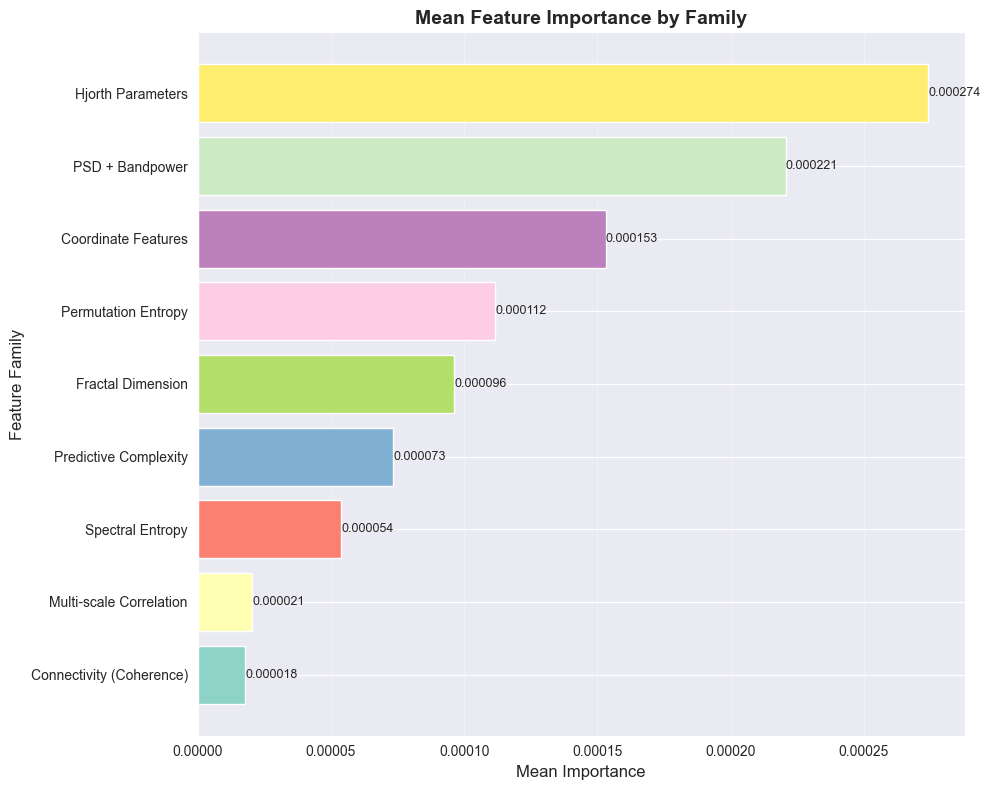

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate family importance
family_importance = {}
for family_name, (start, end) in feature_indices.items():
    family_importance[family_name] = np.mean(importance[start:end])

# Sort for better visualization
sorted_families = sorted(family_importance.items(), key=lambda x: x[1])
families, values = zip(*sorted_families)

# Create color map
colors = plt.cm.Set3(np.linspace(0, 1, len(families)))

plt.figure(figsize=(10, 8))
bars = plt.barh(families, values, color=colors)
plt.xlabel('Mean Importance', fontsize=12)
plt.ylabel('Feature Family', fontsize=12)
plt.title('Mean Feature Importance by Family', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    plt.text(val, bar.get_y() + bar.get_height()/2,
             f'{val:.6f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

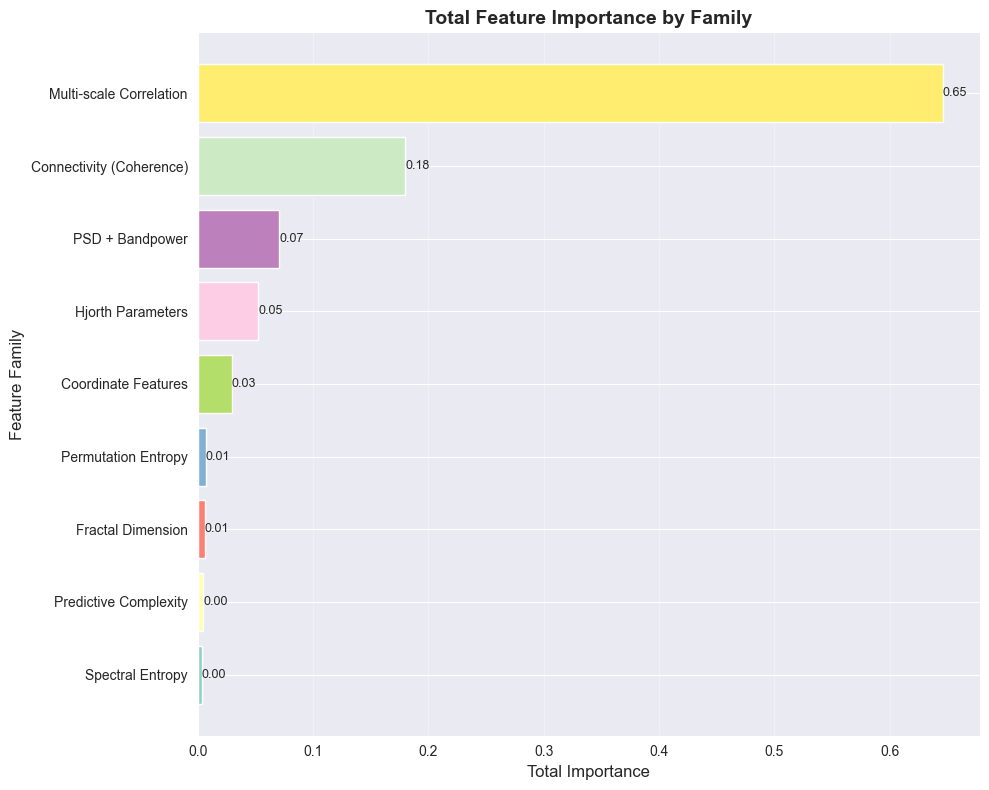

In [40]:
# Calculate total importance per family
family_total = {}
for family_name, (start, end) in feature_indices.items():
    family_total[family_name] = np.sum(importance[start:end])

# Sort for better visualization
sorted_families = sorted(family_total.items(), key=lambda x: x[1])
families, totals = zip(*sorted_families)

plt.figure(figsize=(10, 8))
bars = plt.barh(families, totals, color=colors)
plt.xlabel('Total Importance', fontsize=12)
plt.ylabel('Feature Family', fontsize=12)
plt.title('Total Feature Importance by Family', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, totals)):
    plt.text(val, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_15319/3586253052.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(boxplot_data, labels=family_labels, patch_artist=True)


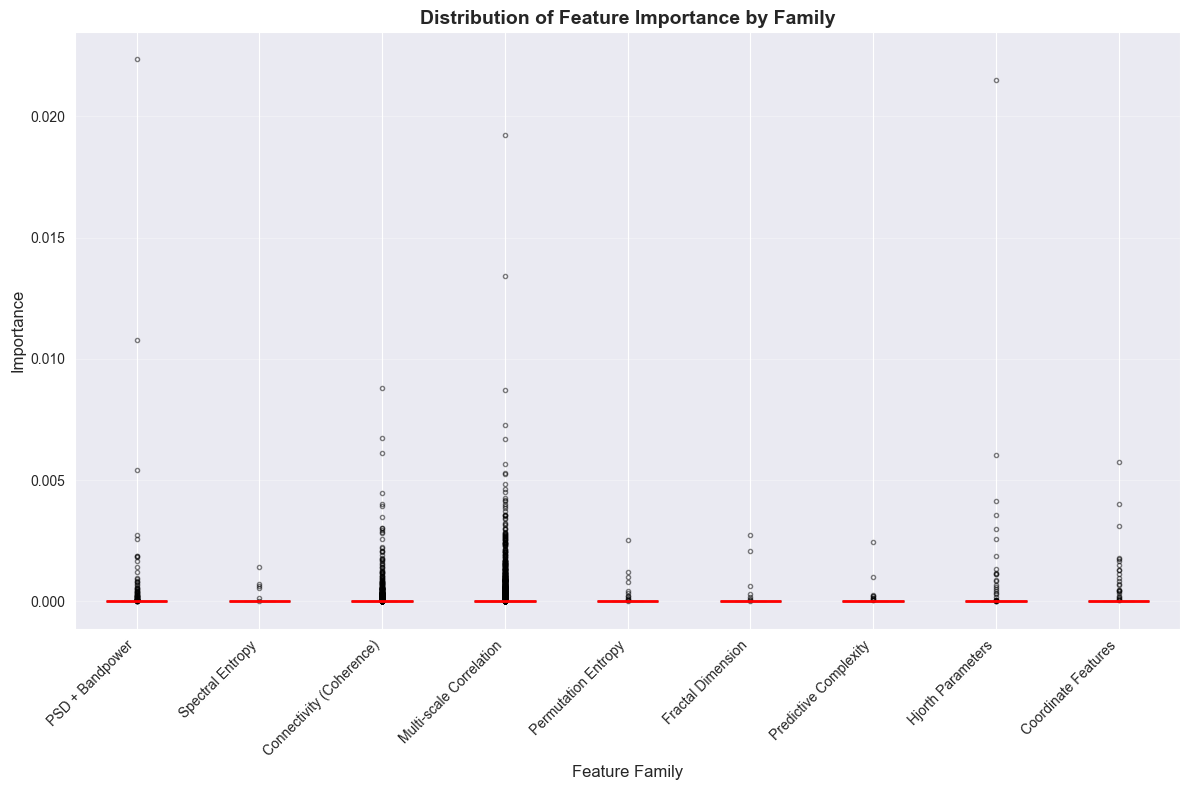

In [41]:
# Prepare data for boxplot
boxplot_data = []
family_labels = []
for family_name in feature_indices.keys():
    start, end = feature_indices[family_name]
    family_imps = importance[start:end]
    if len(family_imps) > 0:
        boxplot_data.append(family_imps)
        family_labels.append(family_name)

plt.figure(figsize=(12, 8))
bp = plt.boxplot(boxplot_data, labels=family_labels, patch_artist=True)
plt.setp(bp['boxes'], facecolor='lightblue', alpha=0.7)
plt.setp(bp['medians'], color='red', linewidth=2)
plt.setp(bp['whiskers'], color='gray', linestyle='--')
plt.setp(bp['caps'], color='gray')
plt.setp(bp['fliers'], marker='o', markersize=3, alpha=0.5)

plt.ylabel('Importance', fontsize=12)
plt.xlabel('Feature Family', fontsize=12)
plt.title('Distribution of Feature Importance by Family', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

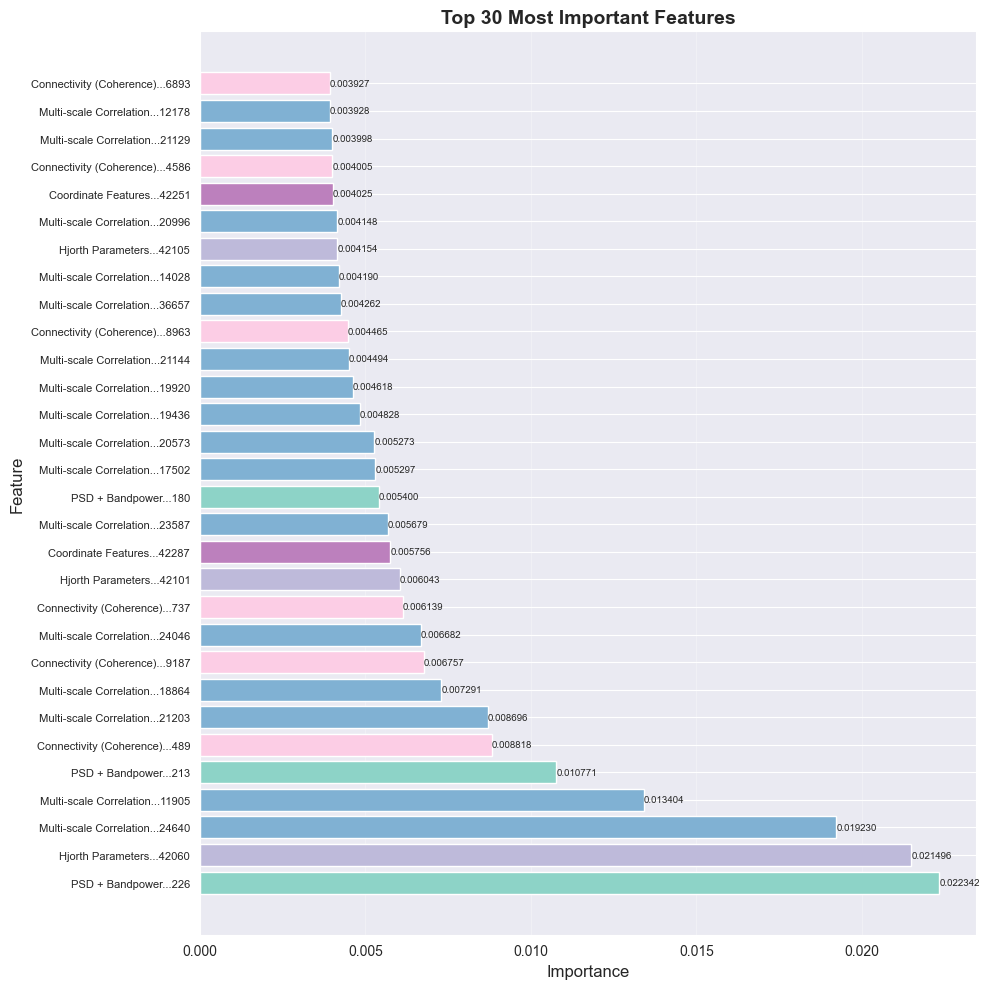

In [42]:
# Create list of all features with their family
all_features = []
for family_name, (start, end) in feature_indices.items():
    for i in range(start, end):
        all_features.append({
            'index': i,
            'family': family_name,
            'importance': importance[i],
            'name': f'{family_name[:20]}_{i-start}'
        })

features_df = pd.DataFrame(all_features)
top_n = 30
top_features = features_df.nlargest(top_n, 'importance')

# Create color map for families in top features
unique_families = top_features['family'].unique()
family_colors = {fam: plt.cm.Set3(i/len(unique_families))
                 for i, fam in enumerate(unique_families)}
colors_top = [family_colors[f] for f in top_features['family']]

plt.figure(figsize=(10, 10))
bars = plt.barh(range(top_n), top_features['importance'].values, color=colors_top)
plt.yticks(range(top_n), [f"{row['family'][:25]}...{row['index']}"
           for _, row in top_features.iterrows()], fontsize=8)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features['importance'].values)):
    plt.text(val, bar.get_y() + bar.get_height()/2,
             f'{val:.6f}', ha='left', va='center', fontsize=7)

plt.tight_layout()
plt.show()

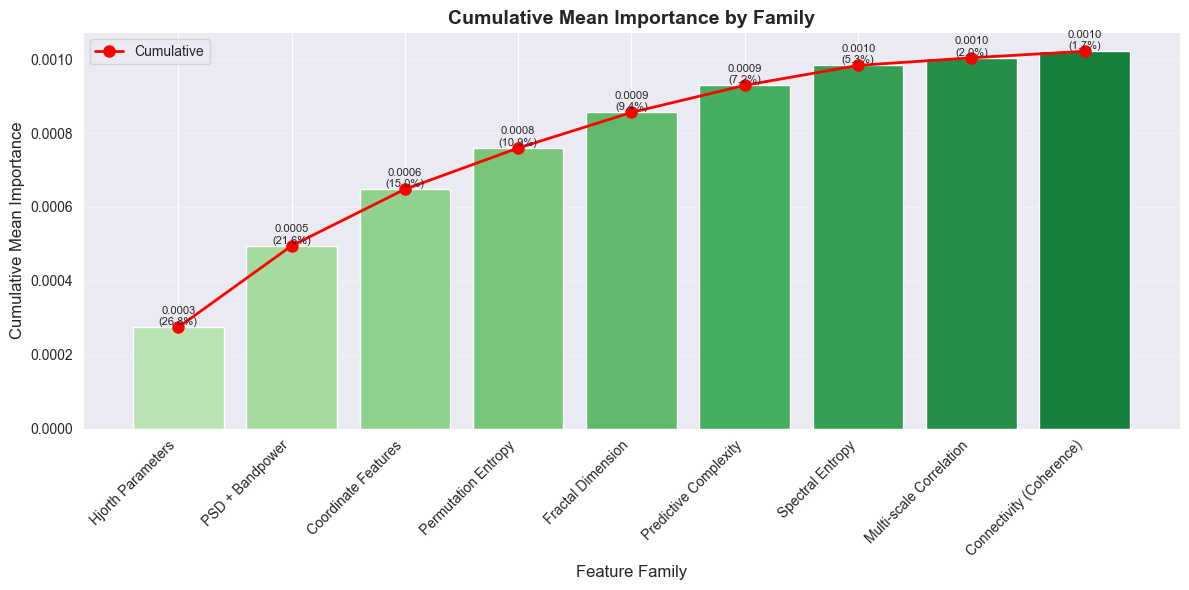

In [43]:
# Sort families by mean importance
sorted_by_mean = sorted(family_importance.items(), key=lambda x: x[1], reverse=True)
families_sorted, mean_imps = zip(*sorted_by_mean)

# Calculate cumulative sum
cumulative = np.cumsum(mean_imps)

plt.figure(figsize=(12, 6))
bars = plt.bar(families_sorted, cumulative, color=plt.cm.Greens(np.linspace(0.3, 0.8, len(families_sorted))))
plt.plot(families_sorted, cumulative, 'ro-', linewidth=2, markersize=8, label='Cumulative')
plt.xlabel('Feature Family', fontsize=12)
plt.ylabel('Cumulative Mean Importance', fontsize=12)
plt.title('Cumulative Mean Importance by Family', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Add percentage labels
total_mean_imp = sum(mean_imps)
for i, (family, cum_val, mean_imp) in enumerate(zip(families_sorted, cumulative, mean_imps)):
    percentage = (mean_imp / total_mean_imp) * 100
    plt.text(i, cum_val, f'{cum_val:.4f}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

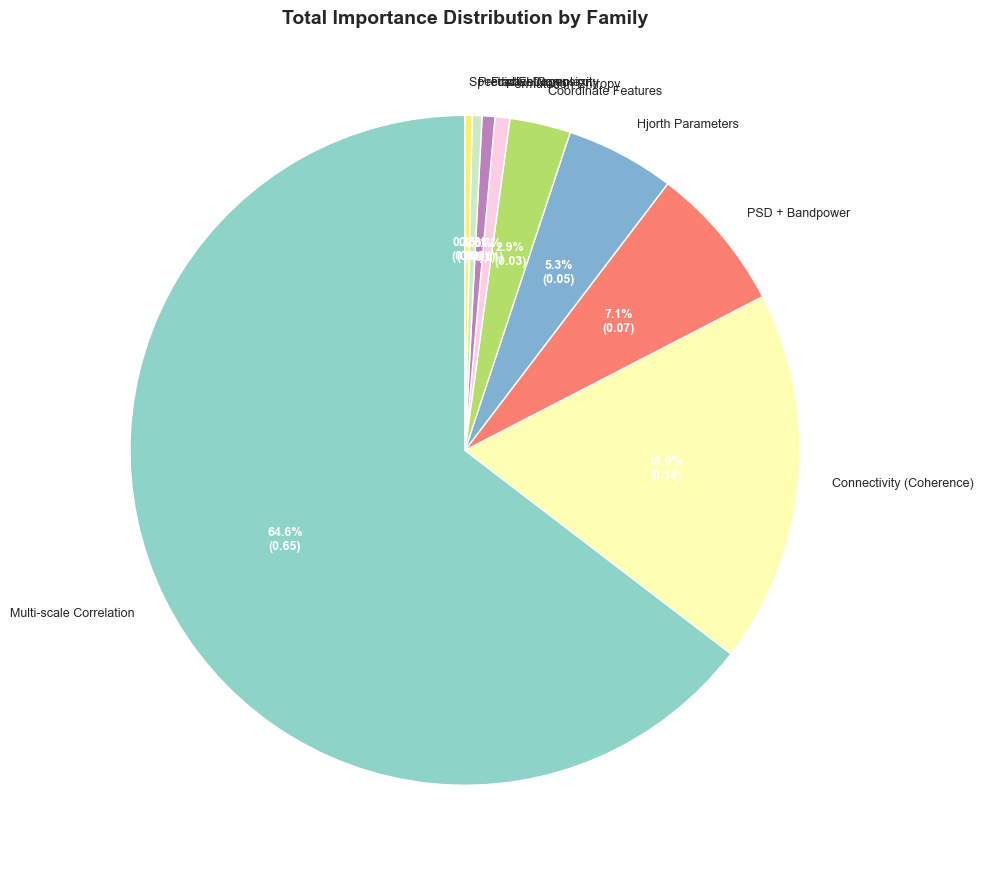

In [44]:
# Calculate total importance for each family
family_total = {}
for family_name, (start, end) in feature_indices.items():
    family_total[family_name] = np.sum(importance[start:end])

# Sort for better visualization
sorted_total = sorted(family_total.items(), key=lambda x: x[1], reverse=True)
families, totals = zip(*sorted_total)

# Create color map
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(families)))

plt.figure(figsize=(10, 10))
wedges, texts, autotexts = plt.pie(totals,
                                    labels=families,
                                    autopct=lambda pct: f'{pct:.1f}%\n({pct/100*sum(totals):.2f})',
                                    colors=colors_pie,
                                    startangle=90,
                                    textprops={'fontsize': 9})

# Style the autotexts
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Total Importance Distribution by Family', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

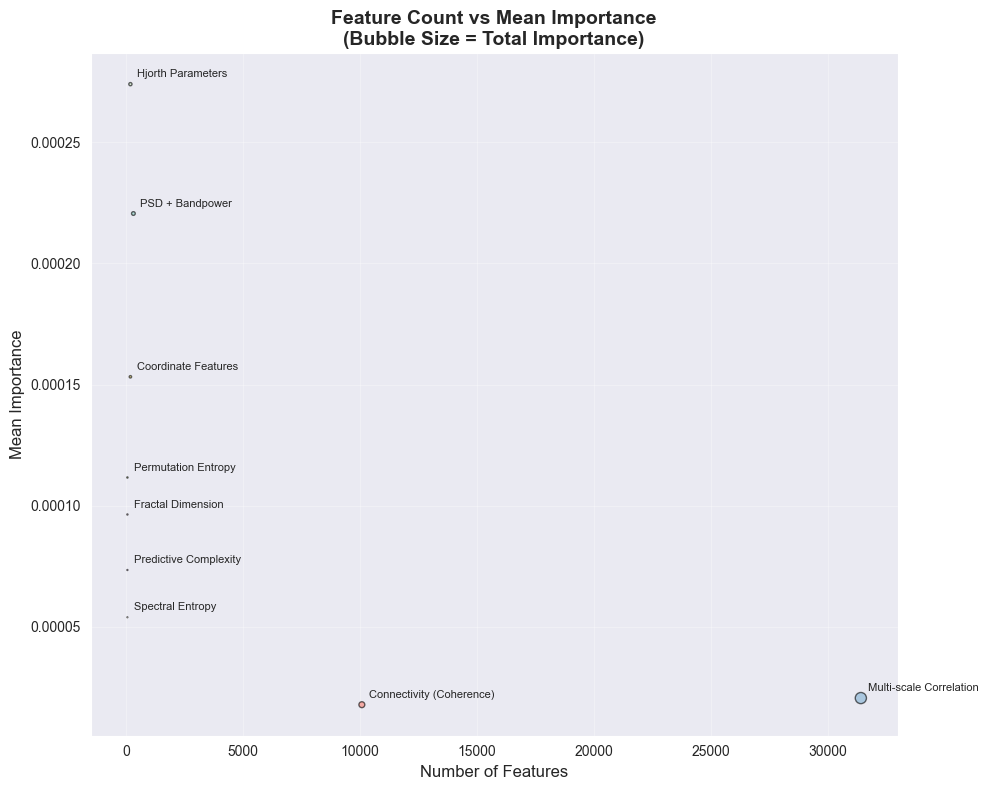

In [47]:
# Calculate metrics for each family
n_features_list = []
mean_importance_list = []
total_importance_list = []
family_names_list = []

for family_name, (start, end) in feature_indices.items():
    n_features = end - start
    mean_imp = family_importance[family_name]
    total_imp = family_total[family_name]

    n_features_list.append(n_features)
    mean_importance_list.append(mean_imp)
    total_importance_list.append(total_imp)
    family_names_list.append(family_name)

# Normalize bubble sizes (multiply by 100 for better visibility)
bubble_sizes = np.array(total_importance_list) * 100

# Create color map
colors_bubble = plt.cm.Set3(np.linspace(0, 1, len(family_names_list)))

plt.figure(figsize=(10, 8))
scatter = plt.scatter(n_features_list, mean_importance_list,
                      s=bubble_sizes, c=colors_bubble,
                      alpha=0.6, edgecolors='black', linewidth=1)

plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Mean Importance', fontsize=12)
plt.title('Feature Count vs Mean Importance\n(Bubble Size = Total Importance)',
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Annotate points
for i, (family, n_feat, mean_imp) in enumerate(zip(family_names_list, n_features_list, mean_importance_list)):
    plt.annotate(family[:25], (n_feat, mean_imp),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()